In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
train_data= pd.read_csv('train_data.csv')
train_data.head()

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,...,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,...,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,...,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,...,0.022066,57.993905,0.003298,0.164309,0.002918,0.386400,89.0,83.0,40.0,14.0
4,0,0.257806,5,-10.391260,-7.852942,9.036838,14510.0,13792.0,478.7,5811.1,...,0.015075,57.946717,0.003670,0.164172,0.003220,0.386388,89.0,83.0,40.0,14.0


In [ ]:
train_data

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,...,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,...,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,...,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,...,0.022066,57.993905,0.003298,0.164309,0.002918,0.386400,89.0,83.0,40.0,14.0
4,0,0.257806,5,-10.391260,-7.852942,9.036838,14510.0,13792.0,478.7,5811.1,...,0.015075,57.946717,0.003670,0.164172,0.003220,0.386388,89.0,83.0,40.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162629,13153,3.029751,1,-7.108630,-5.142668,7.561579,2307.0,14976.0,-472.1,-159.9,...,0.071060,48.480202,0.011479,0.145746,0.002764,0.231577,81.0,84.0,48.0,18.0
162630,13153,2.799253,1,-7.070070,-5.137869,7.471857,2254.0,14976.0,-469.7,-163.3,...,0.063959,48.565132,0.009935,0.145729,0.002678,0.231583,78.0,84.0,49.0,19.0
162631,13153,2.385399,1,-7.066209,-5.137034,7.463470,2259.0,14976.0,-469.3,-158.8,...,0.059657,48.547317,0.009491,0.145745,0.002632,0.231582,78.0,84.0,49.0,19.0
162632,13153,2.043339,1,-7.028307,-5.131297,7.378397,2257.0,14976.0,-465.2,-160.3,...,0.039351,48.540602,0.002612,0.145734,0.002631,0.231583,78.0,84.0,49.0,19.0


In [ ]:
# prompt: train_data.isna().sum()

train_data.isna().sum()


,0
event_id,0
time_to_tca,0
mission_id,0
risk,0
max_risk_estimate,1
...,...
c_sigma_ndot,3744
F10,2460
F3M,2460
SSN,2460


In [ ]:
train_data = train_data.interpolate()
train_data.isnull().sum()

<ipython-input-20-45da9edab40b>:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  train_data = train_data.interpolate()


,0
event_id,0
time_to_tca,0
mission_id,0
risk,0
max_risk_estimate,0
...,...
c_sigma_ndot,0
F10,0
F3M,0
SSN,0


In [ ]:
#Select Frist 14 features
df_copy = train_data[['event_id', 'time_to_tca', 'mission_id', 'risk', 'max_risk_estimate', 'max_risk_scaling', 'miss_distance', 'relative_speed', 'relative_position_r', 'relative_position_t', 'relative_position_n', 'relative_velocity_r', 'relative_velocity_t', 'relative_velocity_n']]
df_copy

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,relative_velocity_n
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,-13666.8,-7.2,-12637.0,-5525.9
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,-13319.8,-7.0,-12637.0,-5525.9
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,-13256.1,-7.0,-12637.0,-5525.9
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,-13350.7,-7.0,-12637.0,-5525.9
4,0,0.257806,5,-10.391260,-7.852942,9.036838,14510.0,13792.0,478.7,5811.1,-13288.0,-7.0,-12637.0,-5525.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25585,2041,3.866025,18,-21.387640,-4.779108,43.083785,11234.0,11071.0,70.8,7477.9,-8383.9,33.4,-8261.6,-7371.1
25586,2041,3.591395,18,-30.000000,-4.820736,68.520417,11152.0,11071.0,58.5,7425.5,-8321.1,33.4,-8261.6,-7371.1
25587,2041,3.343189,18,-30.000000,-4.851706,76.902012,11303.0,11071.0,56.8,7526.3,-8432.7,33.3,-8261.6,-7371.1
25588,2041,2.956117,18,-30.000000,-4.960189,126.856525,11518.0,11071.0,66.1,7667.9,-8594.9,33.2,-8261.6,-7371.1


# **corrolation**

<Axes: >

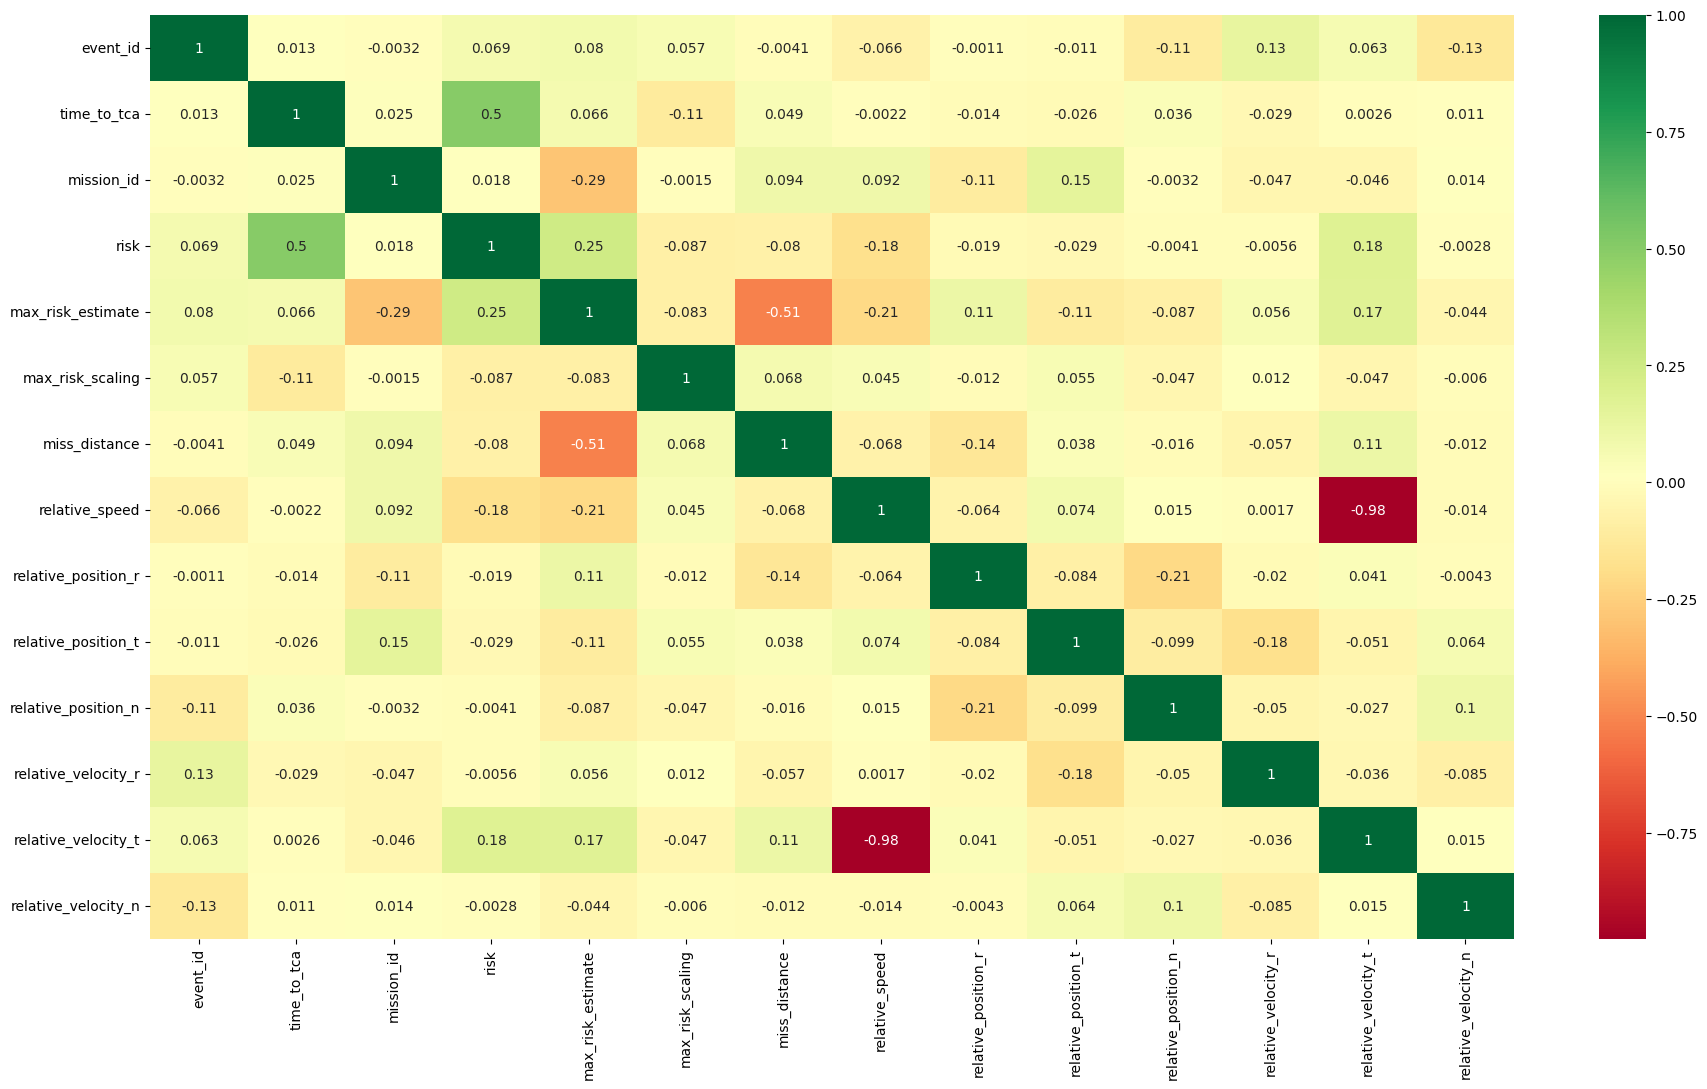

In [ ]:
plt.figure(figsize=(22,12))
sns.heatmap(df_copy.corr(), annot =True, cmap='RdYlGn')

<Axes: title={'center': 'Correlation with risk'}>

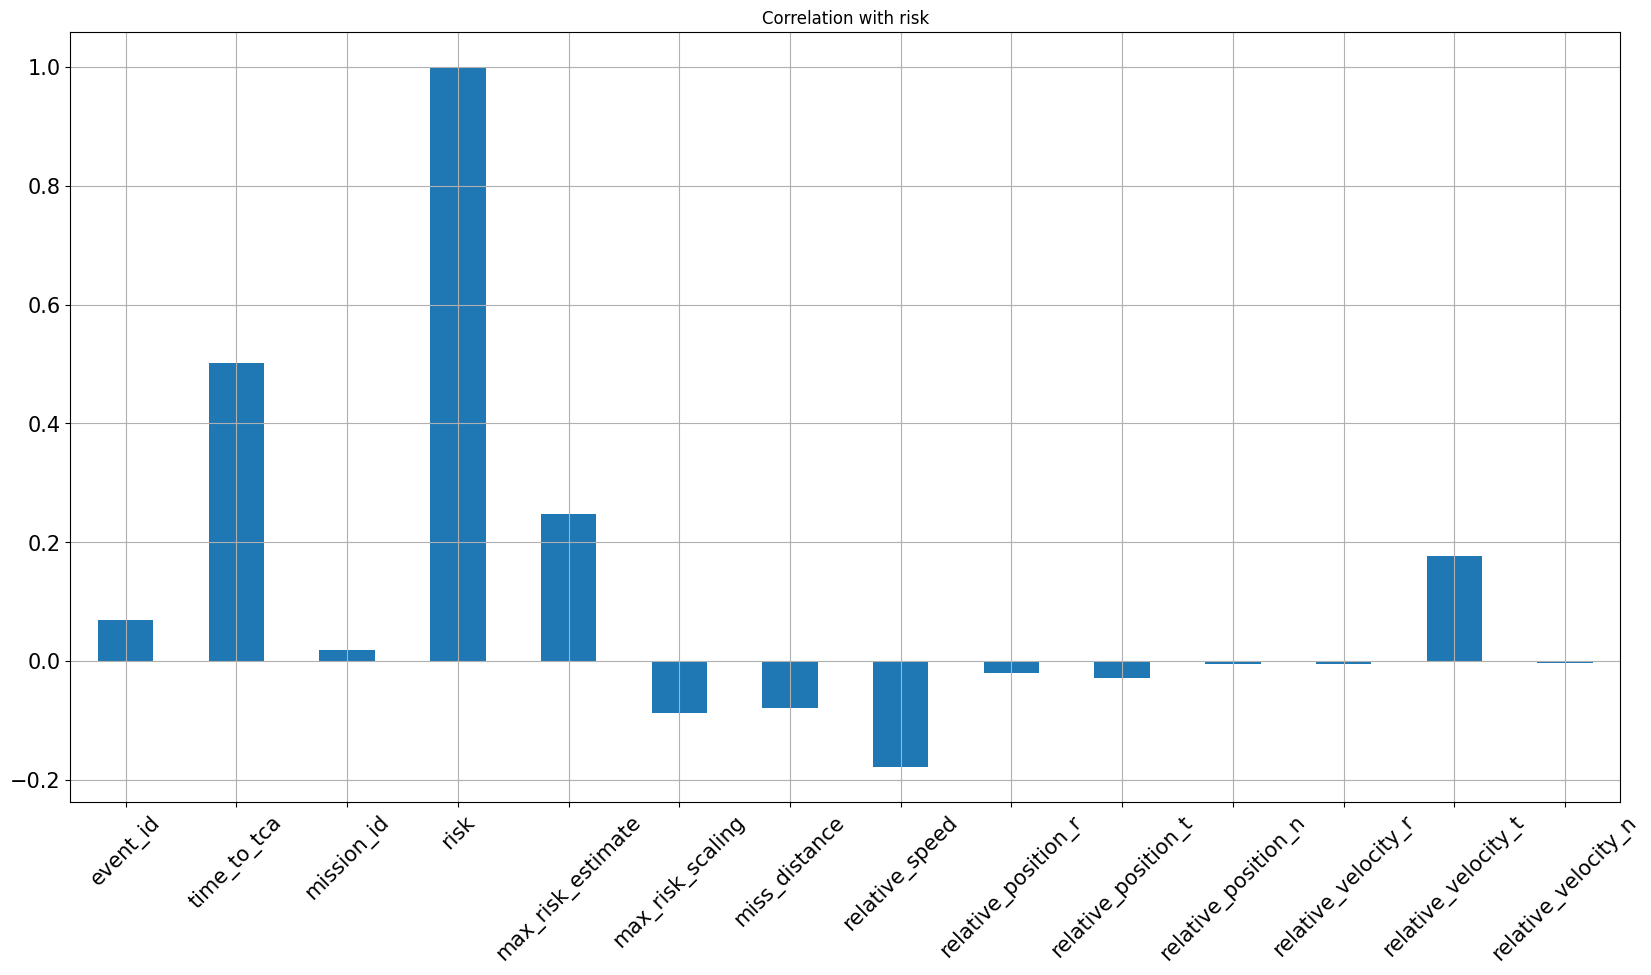

In [ ]:
#df_copy=df_copy.drop(['risk'], axis=1)
df_copy.corrwith(train_data.risk).plot.bar(figsize=(20,10),title="Correlation with risk",fontsize=15,rot=45,grid=True)

<Axes: title={'center': 'Correlation with miss_distance'}>

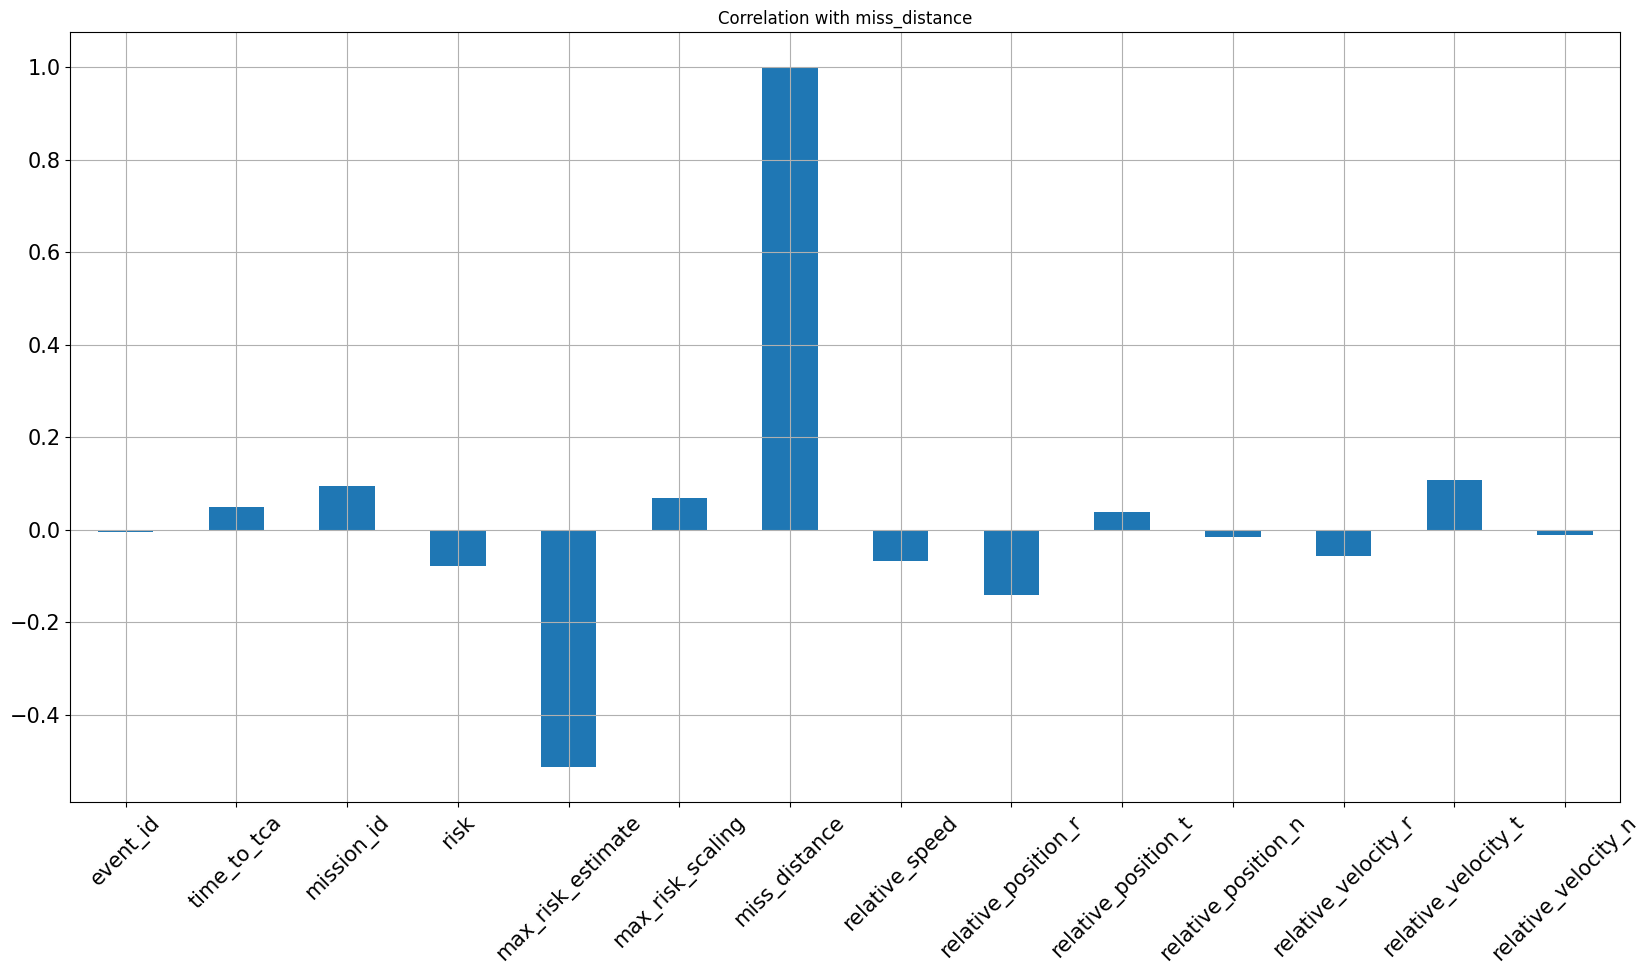

In [ ]:
df_copy.corrwith(train_data.miss_distance).plot.bar(figsize=(20,10),title="Correlation with miss_distance",fontsize=15,rot=45,grid=True)

<Axes: title={'center': 'Correlation with mahalanobis_distance'}>

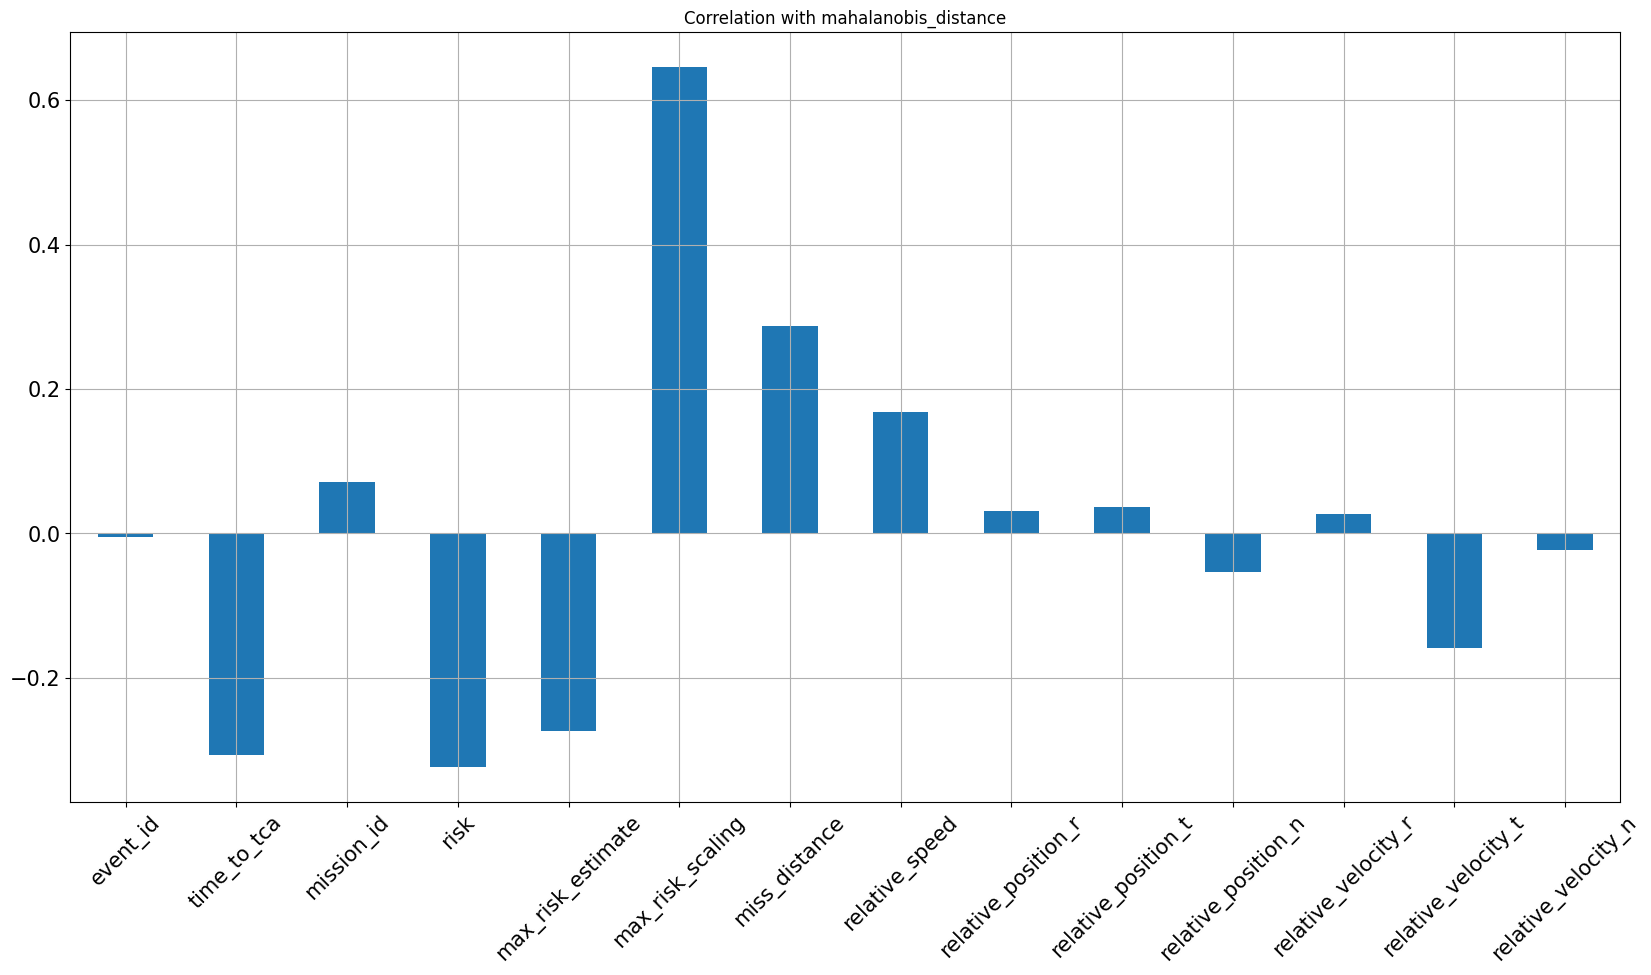

In [ ]:
df_copy.corrwith(train_data.mahalanobis_distance).plot.bar(figsize=(20,10),title="Correlation with mahalanobis_distance",fontsize=15,rot=45,grid=True)

In [ ]:
#Select next 30 features
df_copy1 = train_data[['t_time_lastob_start', 't_time_lastob_end', 't_recommended_od_span', 't_actual_od_span', 't_obs_available', 't_obs_used', 't_residuals_accepted', 't_weighted_rms', 't_rcs_estimate', 't_cd_area_over_mass', 't_cr_area_over_mass', 't_sedr', 't_j2k_sma', 't_j2k_ecc', 't_j2k_inc', 't_ct_r', 't_cn_r', 't_cn_t', 't_crdot_r', 't_crdot_t', 't_crdot_n', 't_ctdot_r', 't_ctdot_t', 't_ctdot_n', 't_ctdot_rdot', 't_cndot_r', 't_cndot_t', 't_cndot_n', 't_cndot_rdot', 't_cndot_tdot']]
df_copy1

,t_time_lastob_start,t_time_lastob_end,t_recommended_od_span,t_actual_od_span,t_obs_available,t_obs_used,t_residuals_accepted,t_weighted_rms,t_rcs_estimate,t_cd_area_over_mass,...,t_crdot_n,t_ctdot_r,t_ctdot_t,t_ctdot_n,t_ctdot_rdot,t_cndot_r,t_cndot_t,t_cndot_n,t_cndot_rdot,t_cndot_tdot
0,1.0,0.0,3.78,3.78,459.0,458.0,98.9,1.265,0.402,0.013826,...,-0.038498,-0.981098,0.214612,-0.316493,-0.210247,0.170737,-0.001551,0.531593,0.002117,-0.179278
1,1.0,0.0,3.79,3.79,456.0,455.0,98.5,1.270,0.402,0.013487,...,-0.052511,-0.994240,-0.029644,-0.302333,0.034030,0.179696,0.001552,0.561142,-0.005165,-0.181036
2,1.0,0.0,3.79,3.80,456.0,455.0,98.5,1.257,0.402,0.013357,...,-0.034287,-0.996674,0.033933,-0.308501,-0.030161,0.123760,0.019630,0.579274,-0.023726,-0.125737
3,1.0,0.0,3.86,3.86,443.0,442.0,98.4,1.254,0.402,0.013490,...,-0.149998,-0.998856,-0.059398,-0.427166,0.072214,0.228051,0.039163,0.547564,-0.049976,-0.229497
4,1.0,0.0,3.86,3.86,440.0,439.0,98.8,1.340,0.402,0.013906,...,-0.243006,-0.999749,-0.430895,-0.405723,0.479990,0.223469,0.118674,0.543475,-0.143542,-0.224060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2215,1.0,0.0,3.26,3.26,182.0,180.0,99.9,1.215,0.052,0.039425,...,-0.024654,-0.879184,0.746100,-0.217298,-0.749522,0.129923,-0.077674,0.299391,0.079276,-0.214491
2216,1.0,0.0,3.53,3.53,173.0,171.0,99.8,1.230,0.052,0.039188,...,0.001660,-0.870354,0.087589,-0.210930,-0.114796,0.125828,0.019825,0.213731,-0.011706,-0.160397
2217,1.0,0.0,3.38,3.38,193.0,191.0,99.9,1.222,0.052,0.039657,...,-0.123751,-0.951536,-0.215205,-0.356492,0.148895,0.261016,0.084956,0.274625,-0.055524,-0.277269
2218,1.0,0.0,3.39,3.39,193.0,191.0,99.9,1.230,0.052,0.039804,...,-0.110386,-0.952757,-0.174922,-0.355742,0.109415,0.216691,0.033673,0.281369,-0.011276,-0.222219


<Axes: >

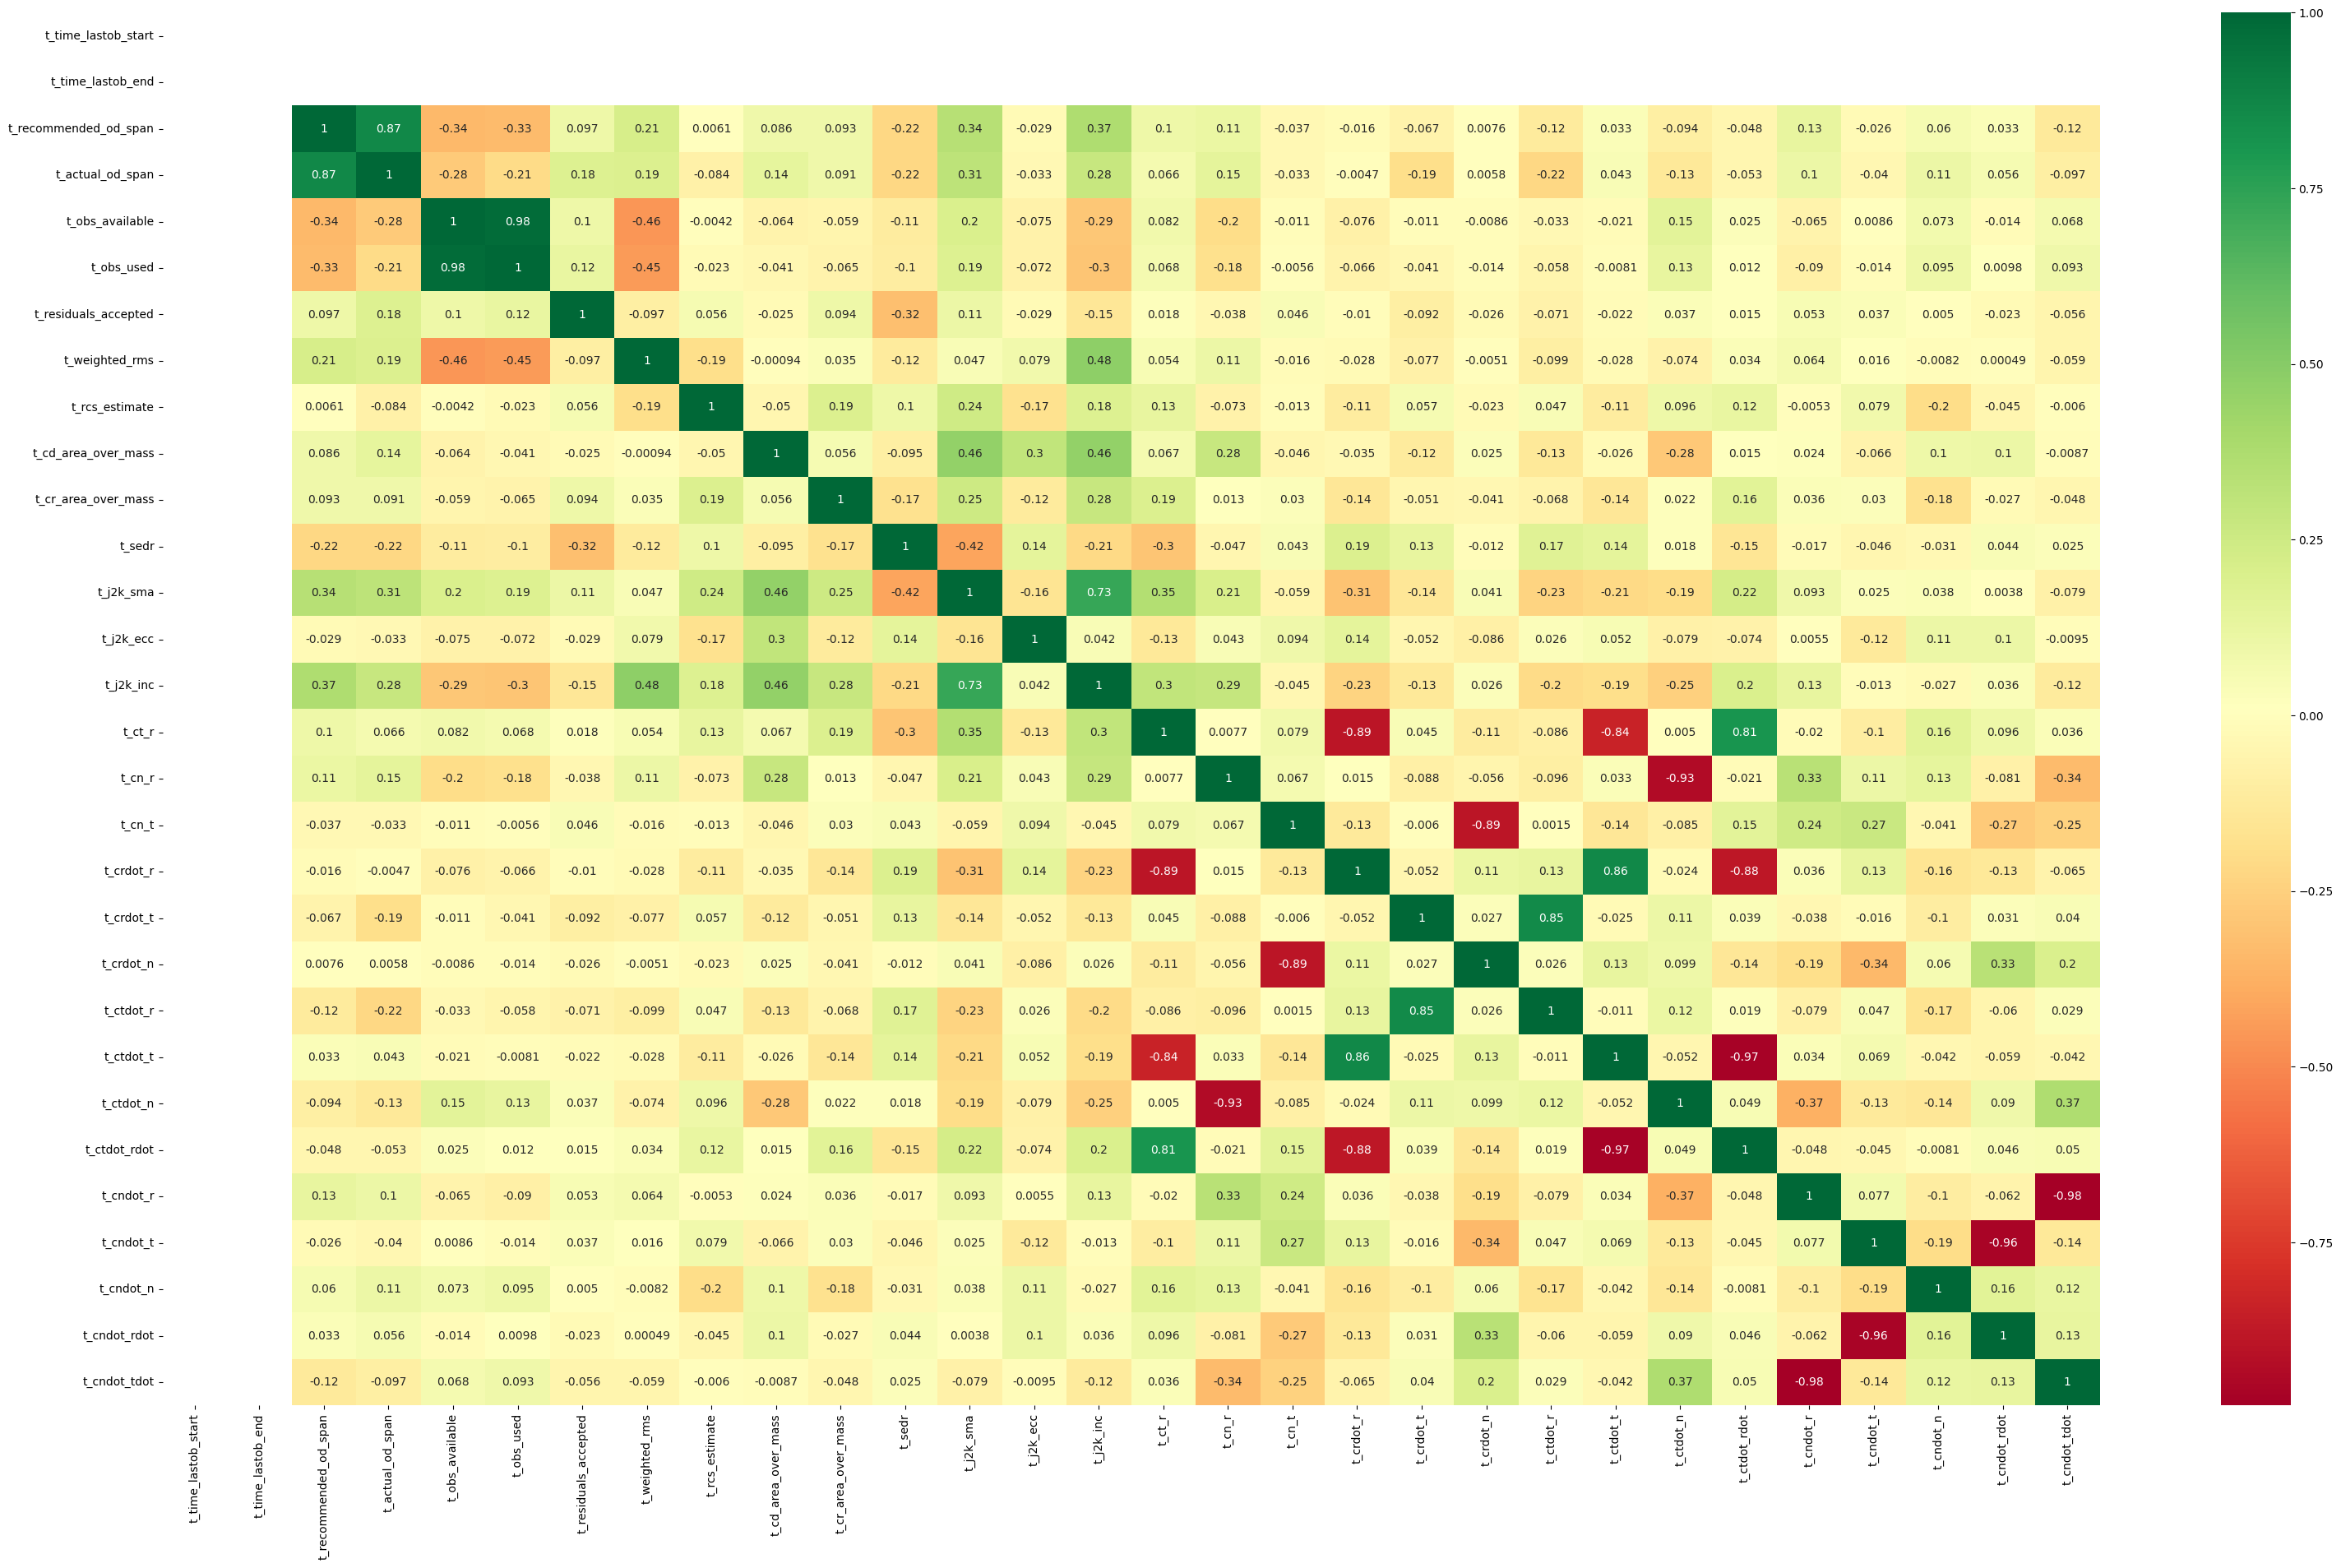

In [ ]:
plt.figure(figsize=(38,22))
sns.heatmap(df_copy1.corr(), annot =True, cmap='RdYlGn')

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: title={'center': 'Correlation with risk'}>

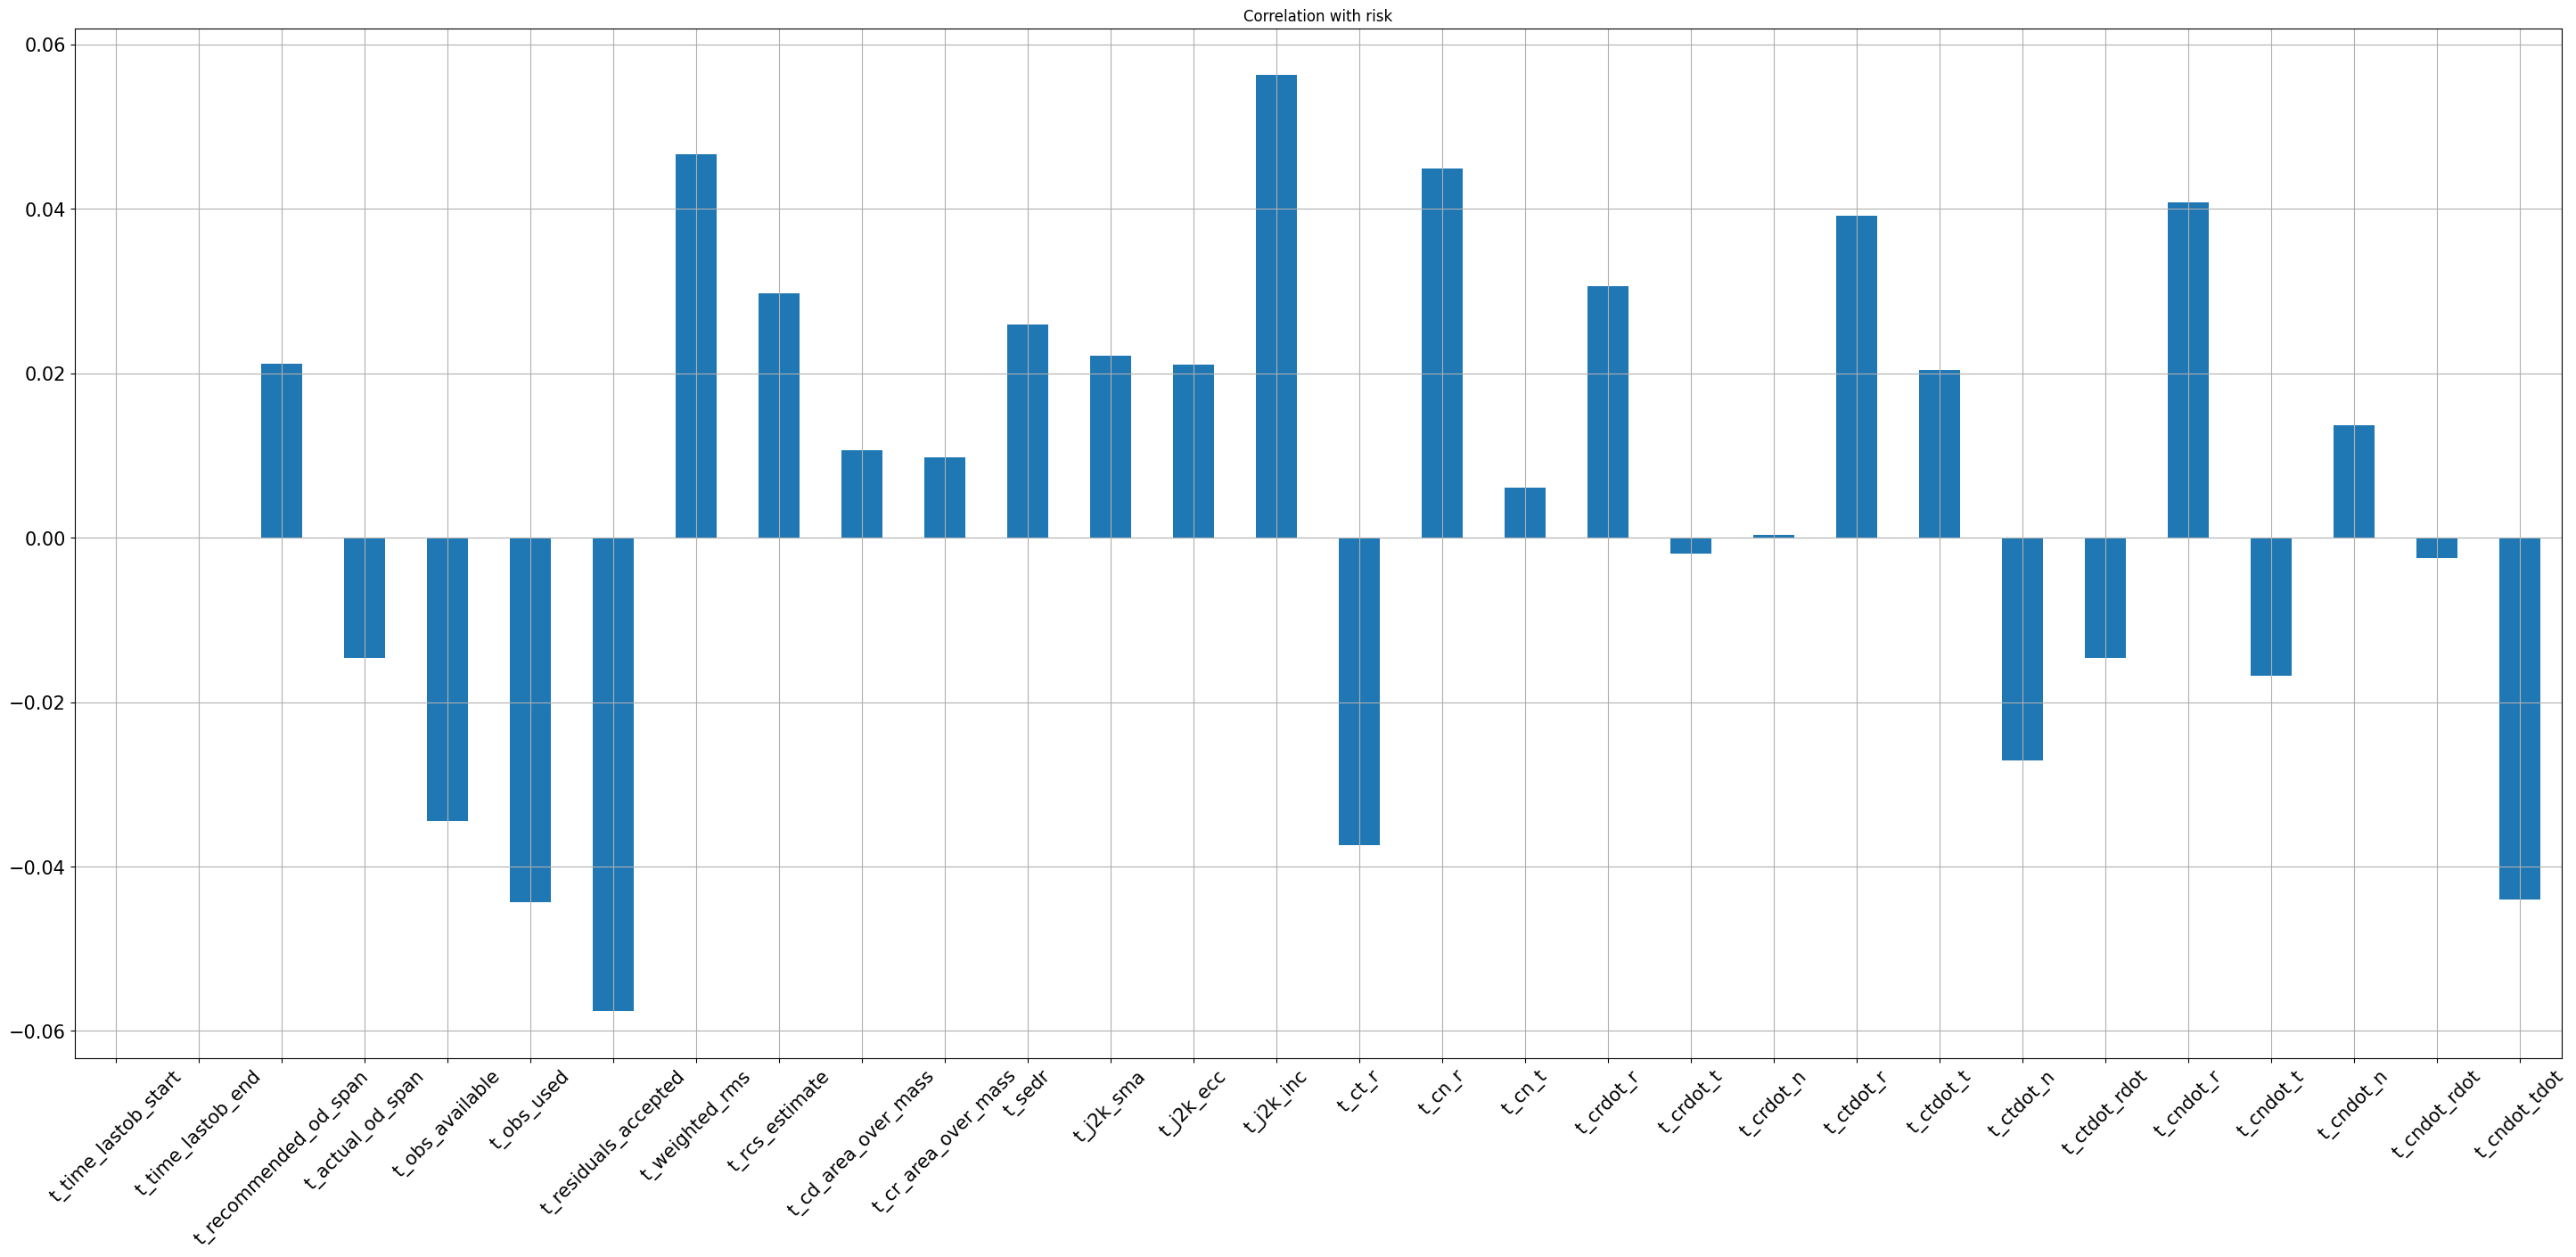

In [ ]:
df_copy1.corrwith(train_data.risk).plot.bar(figsize=(36,15),title="Correlation with risk",fontsize=15,rot=45,grid=True)

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: title={'center': 'Correlation with miss_distance'}>

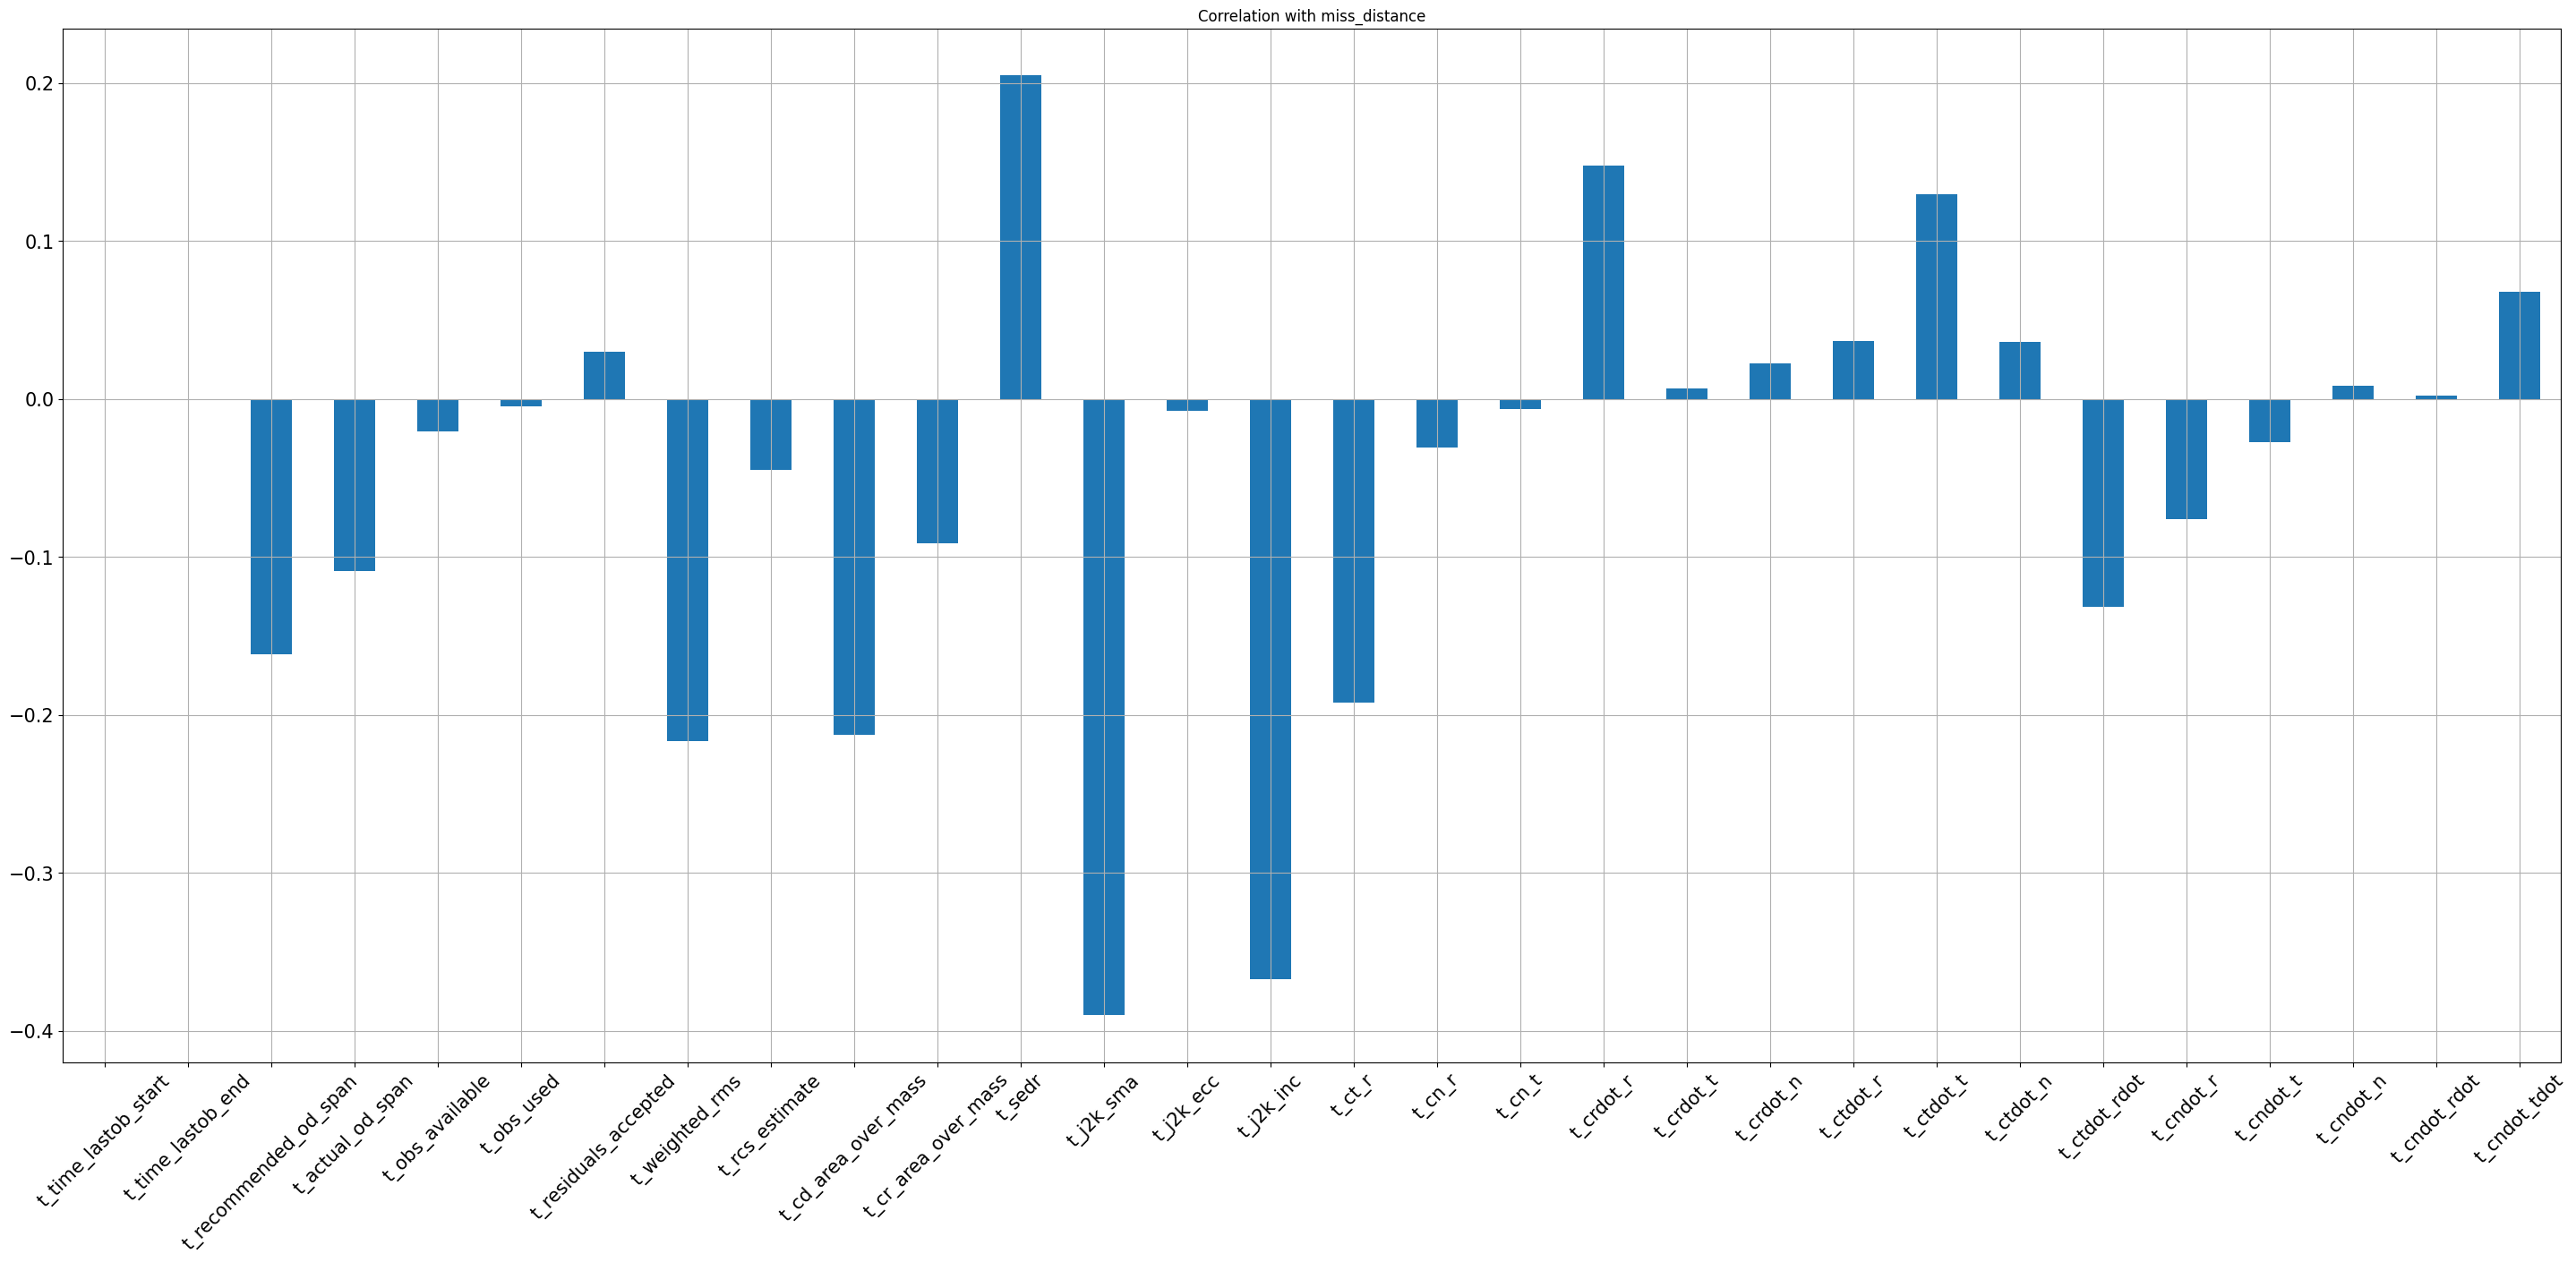

In [ ]:
df_copy1.corrwith(train_data.miss_distance).plot.bar(figsize=(36,15),title="Correlation with miss_distance",fontsize=15,rot=45,grid=True)

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: title={'center': 'Correlation with mahalanobis_distance'}>

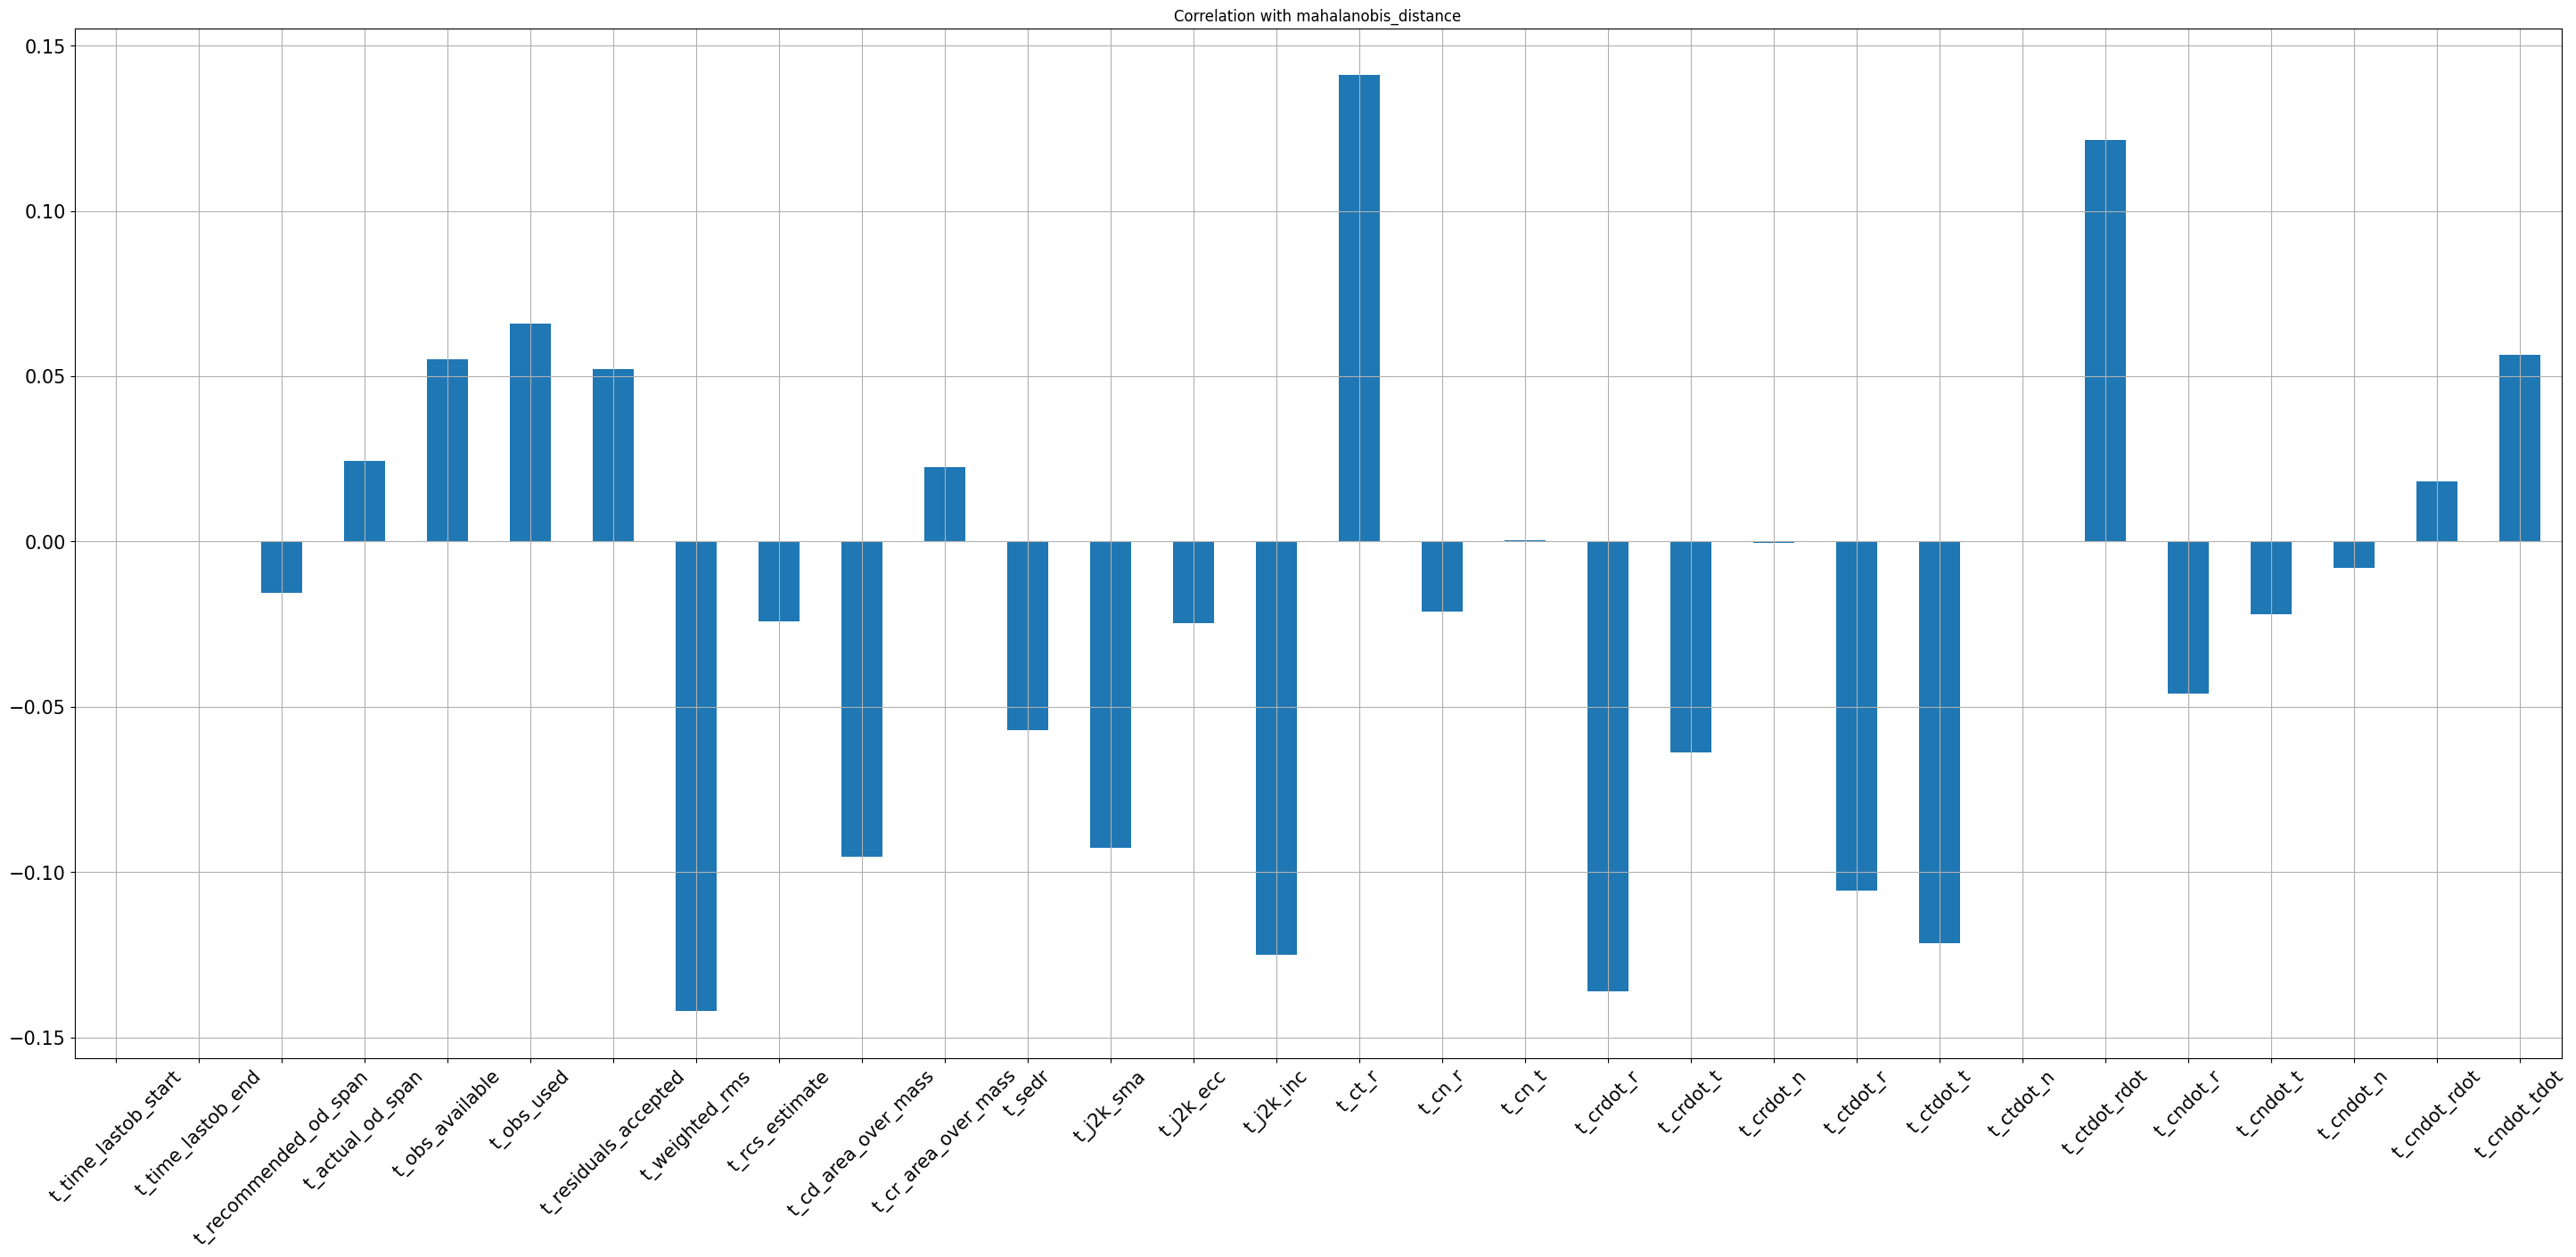

In [ ]:
df_copy1.corrwith(train_data.mahalanobis_distance).plot.bar(figsize=(36,15),title="Correlation with mahalanobis_distance",fontsize=15,rot=45,grid=True)

In [ ]:
#Select next 31 features
df_copy2 = train_data[['c_time_lastob_start', 'c_time_lastob_end', 'c_recommended_od_span', 'c_actual_od_span', 'c_obs_available', 'c_obs_used', 'c_residuals_accepted', 'c_weighted_rms', 'c_rcs_estimate', 'c_cd_area_over_mass', 'c_cr_area_over_mass','c_sedr', 'c_j2k_sma', 'c_j2k_ecc', 'c_j2k_inc', 'c_ct_r', 'c_cn_r', 'c_cn_t', 'c_crdot_r', 'c_crdot_t', 'c_crdot_n', 'c_ctdot_r', 'c_ctdot_t', 'c_ctdot_n', 'c_ctdot_rdot', 'c_cndot_r', 'c_cndot_t', 'c_cndot_n', 'c_cndot_rdot', 'c_cndot_tdot', 't_span']]
df_copy2

,c_time_lastob_start,c_time_lastob_end,c_recommended_od_span,c_actual_od_span,c_obs_available,c_obs_used,c_residuals_accepted,c_weighted_rms,c_rcs_estimate,c_cd_area_over_mass,...,c_ctdot_r,c_ctdot_t,c_ctdot_n,c_ctdot_rdot,c_cndot_r,c_cndot_t,c_cndot_n,c_cndot_rdot,c_cndot_tdot,t_span
0,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,...,-0.732954,0.220006,-0.814249,-0.220621,0.249855,0.196620,0.722186,-0.196908,-0.668487,1.0
1,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,...,-0.728759,0.202595,-0.817490,-0.203216,0.258964,0.195718,0.721903,-0.196008,-0.674979,1.0
2,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,...,-0.729083,0.201698,-0.817662,-0.202320,0.260092,0.195558,0.721854,-0.195849,-0.675347,1.0
3,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,...,-0.728092,0.200534,-0.817883,-0.201155,0.259681,0.195808,0.721874,-0.196097,-0.675656,1.0
4,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,...,-0.727257,0.196662,-0.818575,-0.197284,0.261753,0.195657,0.721794,-0.195947,-0.677041,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2215,1.0,0.0,12.51,12.51,65.0,65.0,99.6,2.004,0.0103,0.154378,...,-0.998303,0.199392,-0.172561,-0.187119,0.379145,0.081256,0.640951,-0.085836,-0.386349,0.1
2216,1.0,0.0,12.24,12.24,68.0,68.0,99.6,1.961,0.0103,0.154797,...,-0.997884,0.073365,-0.270648,-0.053543,0.416350,0.067833,0.689604,-0.075033,-0.421197,0.1
2217,1.0,0.0,11.25,11.25,68.0,68.0,99.6,1.929,0.0103,0.155643,...,-0.998003,-0.016494,-0.308321,0.034518,0.433054,0.013635,0.691968,-0.024281,-0.437275,0.1
2218,1.0,0.0,11.25,11.25,68.0,68.0,99.6,1.929,0.0103,0.155643,...,-0.998108,-0.012684,-0.308469,0.029712,0.433395,0.014567,0.691965,-0.024639,-0.437412,0.1


In [ ]:
train_data.isna().sum()

,0
event_id,0
time_to_tca,0
mission_id,0
risk,0
max_risk_estimate,0
...,...
c_sigma_ndot,0
F10,0
F3M,0
SSN,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df_copy.drop(['risk'], axis=1)
y = df_copy.risk

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=100)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

 # create regressor object
regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)
regressor.fit(X_train,y_train)
predR = regressor.predict(X_test)
rmseR = np.sqrt(mean_squared_error(y_test, predR))
mseR=mean_squared_error(y_test,predR)
maeR=mean_absolute_error(y_test,predR)
r2R=r2_score(y_test,predR)
result1=[rmseR,mseR,maeR,r2R]
df_R = pd.DataFrame({'RandomForestRegressor':result1},index=['RMSE:','MSE:','MAE:','R2-score:'])
df_R

,RandomForestRegressor
RMSE:,0.662585
MSE:,0.439019
MAE:,0.144051
R2-score:,0.995800


In [ ]:
from sklearn.svm import SVR
regressor = SVR(kernel ='sigmoid')
regressor.fit(X_train,y_train)
y_pred = regressor.predict(X_test)
rmseSV = np.sqrt(mean_squared_error(y_test, y_pred ))
mseSV=mean_squared_error(y_test,y_pred )
maeSV=mean_absolute_error(y_test,y_pred )
r2SV=r2_score(y_test,y_pred)
result2=[rmseSV,mseSV,maeSV,r2SV]
df_SV = pd.DataFrame({'RandomForestRegressor':result2},index=['RMSE:','MSE:','MAE:','R2-score:'])
df_SV

,RandomForestRegressor
RMSE:,11.955846
MSE:,142.942245
MAE:,10.159118
R2-score:,-0.367434


# **counting**

<ipython-input-10-ffcee9500a29>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=df_copy['event_id'], kind='count', data=df_copy, palette="Set3")


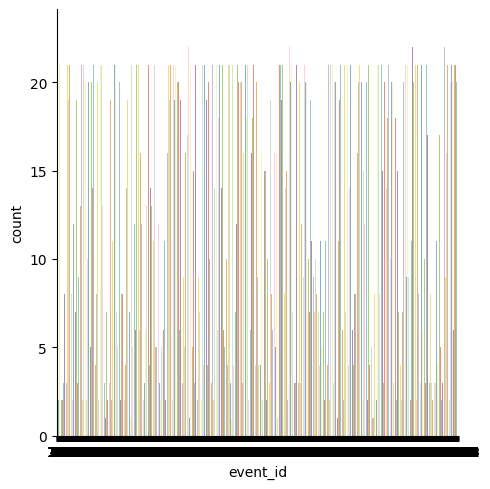

In [ ]:
sns.catplot(x=df_copy['event_id'], kind='count', data=df_copy, palette="Set3")

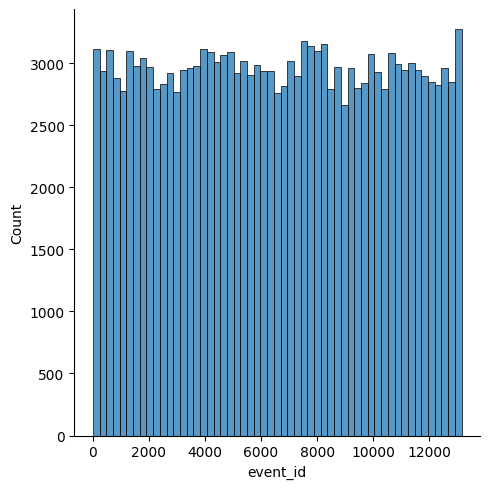

In [ ]:
sns.displot(train_data["event_id"])

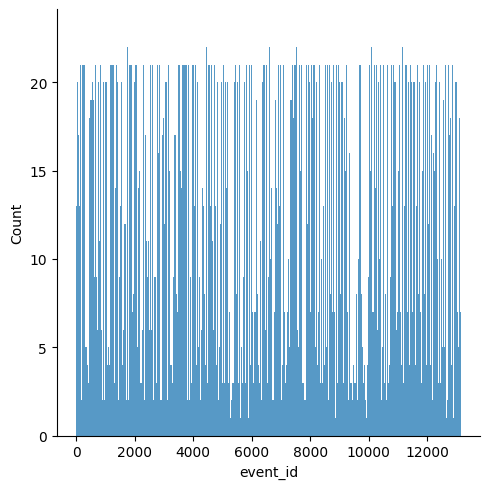

In [ ]:
sns.displot(df_copy["event_id"])

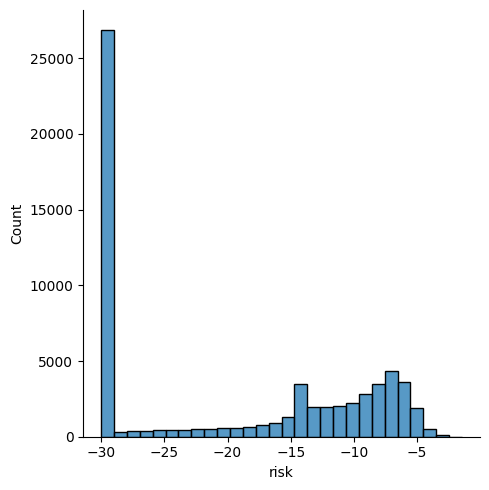

In [ ]:
sns.displot(train_data["risk"])

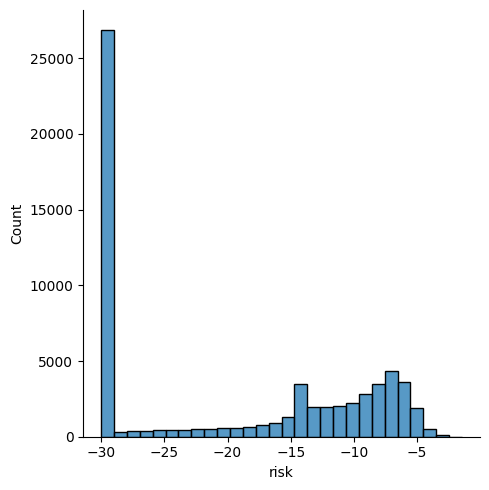

In [ ]:
df1=train_data
df1.drop_duplicates()
sns.displot(df1["risk"])

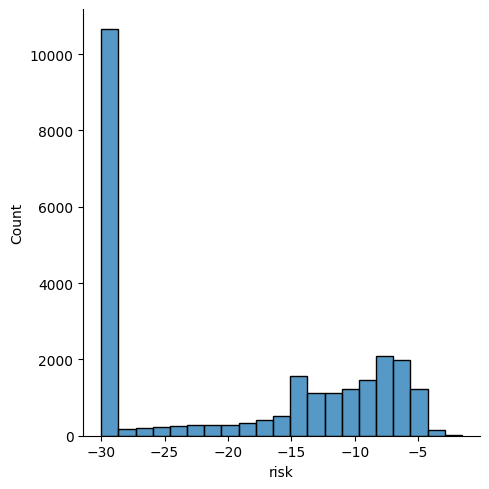

In [ ]:
sns.displot(df_copy["risk"])

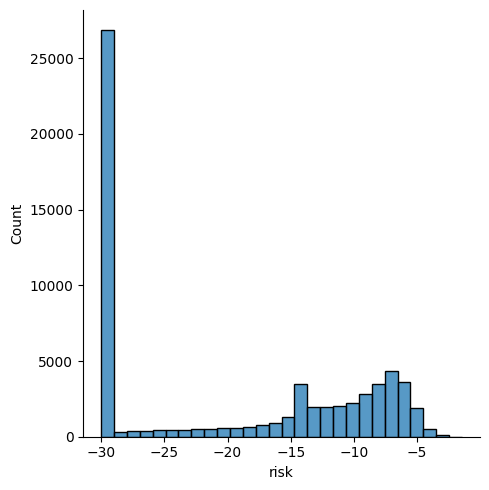

In [ ]:
df_copy1 = train_data[['event_id', 'mission_id', 'risk', 'max_risk_estimate', 'max_risk_scaling', 'miss_distance']]
sns.displot(df_copy1["risk"])

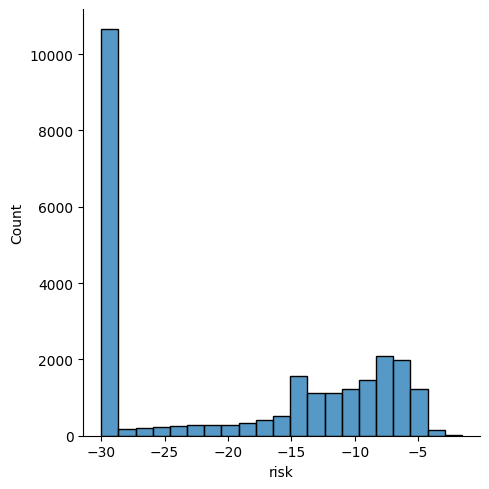

In [ ]:
df1=train_data.drop_duplicates()
sns.displot(df1["risk"])

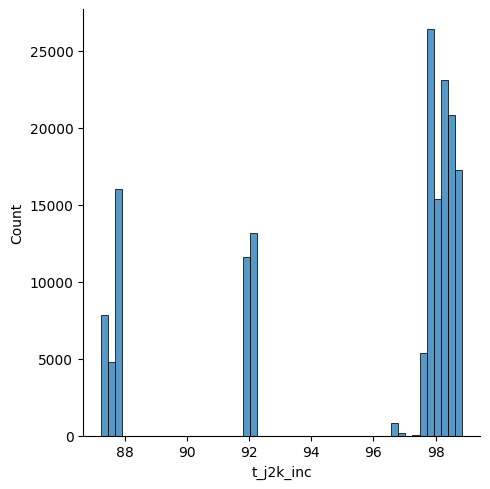

In [ ]:
sns.displot(train_data["t_j2k_inc"])

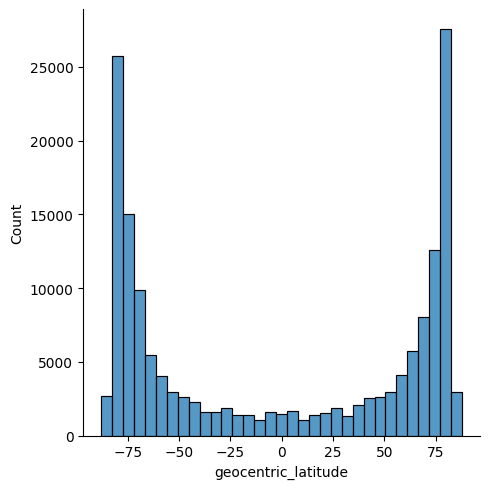

In [ ]:
sns.displot(train_data["geocentric_latitude"])

<ipython-input-11-0d66d34b6bd9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy["event_id"] = df_copy["event_id"].astype('category')
<ipython-input-11-0d66d34b6bd9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.catplot(x=col, kind="count", data=df_copy, palette="Set3")
<ipython-input-11-0d66d34b6bd9>:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(axes[0].get_xmajorticklabels(), rotation=90, fontsize = 13)
<ipython-input-11-0d66d34b6bd9>:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_ytick

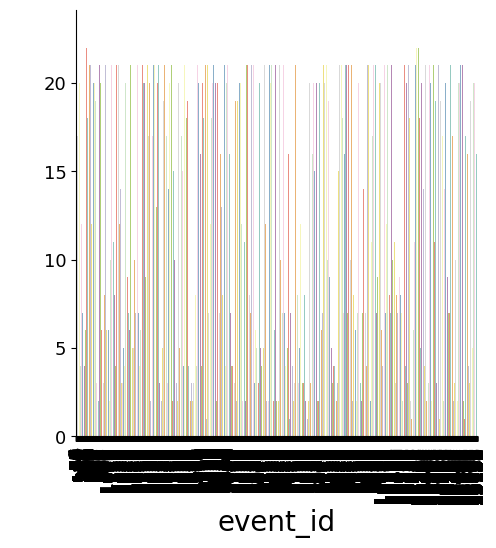

In [ ]:
df_copy["event_id"] = df_copy["event_id"].astype('category')

for col in df_copy.select_dtypes(include='category').columns:
        fig = sns.catplot(x=col, kind="count", data=df_copy, palette="Set3")
        axes = fig.axes.flatten()
        axes[0].set_xlabel(col,fontsize=20)
        axes[0].set_ylabel(" ",fontsize=20)
        axes[0].set_xticklabels(axes[0].get_xmajorticklabels(), rotation=90, fontsize = 13)
        axes[0].set_yticklabels(axes[0].get_ymajorticklabels(), fontsize = 13)
        plt.show()


# **secont attempt**

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
%matplotlib inline

In [ ]:
df = pd.read_csv("train_data.csv")
timestep = 1 #from 1 to 23 (17 with the current NaN strategy)
scaling = False #NOT WORKING YET
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
selected_features = ["risk", "time_to_tca","c_time_lastob_end",
            "c_time_lastob_start", "mahalanobis_distance",
            "max_risk_estimate", "max_risk_scaling",
            "miss_distance", "c_sigma_t", "relative_velocity_t",
            "event_length" , "c_actual_od_span", "c_recommended_od_span"
           ]

In [ ]:
#Getting y as 1D-array
y = df["risk"]

#Scaling y
if(scaling):
    _ = y_scaler.fit(df["risk"].values.reshape(-1, 1)) #using the whole risk feature to scale the target 'y'
    y = y_scaler.transform(y)



#Scaling X
if(scaling):
    df = pd.DataFrame(X_scaler.fit_transform(df), columns=df.columns)

#Shifting features
features = list(df.columns)
X = pd.DataFrame()

for feature in features:
    for i in range(timestep-1,-1,-1):
        X[feature+'_t-'+str(i)] = df[feature].shift(i)

#Getting last row -> getting one row per event
X = X.groupby(["event_id_t-0"]).apply(lambda x: x.iloc[-1])
X = X.reset_index(drop=True)

#Deleting rows with more than one event_id
for i in range(timestep):
    X = X.loc[X["event_id_t-0"]==X["event_id_t-"+str(i)]]

#Dropping y values not included in X due to last condition
y = np.take(y, X.index)
y = y.reshape(-1, 1)

#Deleting event_id features
event_features = [feature for feature in list(X.columns) if feature.startswith('event_id_t-')]
X = X.drop(event_features, axis=1)

#adding targe feature to risk target
shifted_features = []
selected_features.append("mission_id")
selected_features.append("c_object_type")

for feature in selected_features:
    for shift in range(timestep):
        shifted_features.append(feature+"_t-"+str(shift))

X = X[shifted_features]
X["target_risk"] = y
df = X
df["mission_id_t-0"] = df["mission_id_t-0"].astype('category')
df["c_object_type_t-0"] = df["c_object_type_t-0"].astype('category')
df

KeyError: 'risk'